# Missing Value Handling Using Forward Fill and Backward Fill

This notebook demonstrates how to load a dataset, check for missing values, apply **forward fill (ffill)** and **backward fill (bfill)** imputation techniques, and visualize their impact on the dataset.

## 1. Import Required Libraries

In this step, we import the necessary Python libraries for data analysis, data manipulation, and visualization.

- **NumPy**: Numerical and mathematical operations  
- **Pandas**: Data manipulation and analysis  
- **Matplotlib**: Data visualization  


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

The dataset(SalariesKNN.csv) is loaded from a CSV file using pandas.  
This dataset contains missing values that will be handled using forward and backward filling method

In [34]:
df = pd.read_csv("SalariesKNN.csv")

## 3. Check for Missing (Null) Values

We examine the dataset to determine whether any missing (null) values exist.

- Identify columns containing missing values  
- Count the total number of null values in each column  

This step confirms whether imputation is required.

In [35]:
df.isnull()

,Age,Salary,Experience,Class
0,False,False,False,False
1,False,True,False,False
2,False,False,True,False
3,True,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,True,False
7,True,False,False,False
8,False,True,False,False
9,False,False,False,False


In [36]:
df

,Age,Salary,Experience,Class
0,25.0,50.0,2.0,0
1,28.0,NaN,4.0,1
2,32.0,60.0,NaN,0
3,NaN,80.0,6.0,1
4,40.0,90.0,10.0,1
5,30.0,55.0,5.0,0
6,27.0,52.0,NaN,0
7,NaN,120.0,12.0,1
8,29.0,NaN,3.0,0
9,35.0,70.0,7.0,1


## 4. Extract All Features

All feature columns are extracted from the dataset and stored in a separate variable.

- These features will be used for applying imputation methods  
- Ensures consistency when filling missing values across the dataset 

In [ ]:
# df_new.sort_values("Age", inplace=True)
# df_new.reset_index(drop=False, inplace=False)
print(df)
features = [
    "Age",
    "Salary",
    "Experience"
]

X = df[features].copy()
y = df['Class']

    Age  Salary  Experience  Class
0  25.0    50.0         2.0      0
1  28.0     NaN         4.0      1
2  32.0    60.0         NaN      0
3   NaN    80.0         6.0      1
4  40.0    90.0        10.0      1
5  30.0    55.0         5.0      0
6  27.0    52.0         NaN      0
7   NaN   120.0        12.0      1
8  29.0     NaN         3.0      0
9  35.0    70.0         7.0      1


## 5. Apply Forward Fill (ffill)

Forward fill replaces missing values with the **previous valid observation** in the column.

- Suitable for time-series or sequential data  
- Assumes values change gradually over time 

In [40]:
df_ffill = df.ffill()
df_ffill

,Age,Salary,Experience,Class
0,25.0,50.0,2.0,0
1,28.0,50.0,4.0,1
2,32.0,60.0,4.0,0
3,32.0,80.0,6.0,1
4,40.0,90.0,10.0,1
5,30.0,55.0,5.0,0
6,27.0,52.0,5.0,0
7,27.0,120.0,12.0,1
8,29.0,120.0,3.0,0
9,35.0,70.0,7.0,1


## 6. Apply Backward Fill (bfill)

Backward fill replaces missing values with the **next valid observation** in the column.

- Useful when future values are more reliable  
- Often applied in ordered or time-dependent datasets  

In [42]:
df_new = df.copy()
df

,Age,Salary,Experience,Class
0,25.0,50.0,2.0,0
1,28.0,NaN,4.0,1
2,32.0,60.0,NaN,0
3,NaN,80.0,6.0,1
4,40.0,90.0,10.0,1
5,30.0,55.0,5.0,0
6,27.0,52.0,NaN,0
7,NaN,120.0,12.0,1
8,29.0,NaN,3.0,0
9,35.0,70.0,7.0,1


In [43]:
df_bfill = df.bfill()
df_bfill


,Age,Salary,Experience,Class
0,25.0,50.0,2.0,0
1,28.0,60.0,4.0,1
2,32.0,60.0,6.0,0
3,40.0,80.0,6.0,1
4,40.0,90.0,10.0,1
5,30.0,55.0,5.0,0
6,27.0,52.0,12.0,0
7,29.0,120.0,12.0,1
8,29.0,70.0,3.0,0
9,35.0,70.0,7.0,1


## 8. Visualization of Results (Forward Fill and Backward Fill)

After applying **ffill** and **bfill**, visualizations are created to analyze their effects.

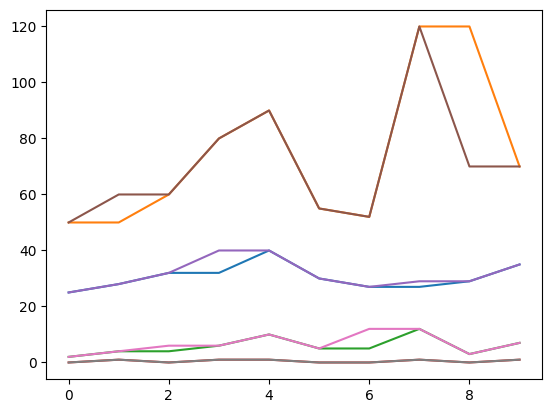

In [48]:
plt.plot(df_ffill)
plt.plot(df_bfill)
plt.show()

### Visualization Techniques
- **Line plots** for time-series or ordered data  
- **Histograms** to compare distributions  
- **Box plots** to observe spread and outliers  


## Train Test Split
